# Лабораторная работа № 1 — часть 2
## Разведочный анализ обработанного датасета Lending Club Loans Data

Во второй части лабораторной работы выполняется более подробный разведочный анализ уже подготовленного набора данных, который был создан в первой части.

### Что сделано в первой части
В первой части лабораторной работы:
- исходный CSV-файл был прочитан из **HDFS**;
- были выбраны основные столбцы для анализа;
- строки были очищены от явных ошибок и дубликатов;
- числовые и временные признаки были приведены к корректным типам;
- подготовленный набор данных был сохранён в таблицу **Apache Iceberg**.

### Что будет сделано во второй части
Во второй части мы:
1. загрузим подготовленную таблицу из Iceberg;
2. проверим её структуру и размер;
3. проанализируем пропуски;
4. рассмотрим несколько ключевых признаков:
   - `issue_date`
   - `loan_status`
   - `grade`
   - `purpose`
   - `loan_amnt`
   - `int_rate`
   - `annual_inc`
   - `dti`
5. построим графики и интерпретируем их;
7. сохраним финальный обработанный датафрейм в новую таблицу Iceberg.

### Используемая таблица
`spark_catalog.khramtsov_database.sobd_lab1_lending_club_table`


## Подключение библиотек

Ниже подключаются:
- **matplotlib** — для построения графиков;
- **pandas** — для перевода небольших агрегатов в формат, удобный для визуализации;
- **pyspark** — для работы с большими данными в Spark.


In [1]:
# Библиотека для визуализации графиков
import matplotlib.pyplot as plt

# Pandas используется для перевода небольших таблиц в локальный формат
# перед построением графиков
import pandas as pd

# builtins нужен для обычного питоновского round()
import builtins

# Основные компоненты Spark
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf

# Подключаем Spark-функции для агрегаций и работы со столбцами
from pyspark.sql.functions import (
    col,
    count,
    avg,
    round as spark_round,
    min as spark_min,
    max as spark_max
)


## Формирование конфигурации Spark

В этой ячейке создаётся объект `SparkConf`, который задаёт параметры Spark-сессии.

### Важные моменты конфигурации
- `master = local[*]` означает локальный запуск на всех доступных ядрах;
- указывается адрес HDFS;
- подключается поддержка Apache Iceberg;
- задаётся каталог warehouse, где Spark будет хранить Iceberg-таблицы.

Эта функция полностью аналогична логике первой части лабораторной работы.


In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создаёт и настраивает SparkConf для локального выполнения в docker-контейнере.
    Также конфигурация включает доступ к HDFS и Iceberg.
    """
    user_name = "jovyan"

    conf = SparkConf()

    # Название Spark-приложения
    conf.setAppName("Lab1_Lending_Club_EDA_Part2")

    # Локальный запуск на всех доступных вычислительных ядрах
    conf.setMaster("local[*]")

    # Включаем адаптивное выполнение Spark SQL
    conf.set("spark.sql.adaptive.enabled", "true")

    # Настройки ресурсов
    conf.set("spark.executor.memory", "6g")
    conf.set("spark.executor.cores", "2")
    conf.set("spark.executor.instances", "1")
    conf.set("spark.driver.memory", "4g")
    conf.set("spark.driver.cores", "1")

    # Адрес HDFS
    conf.set("spark.hadoop.fs.defaultFS", "hdfs://hadoop-namenode:9820")
    conf.set("spark.hadoop.dfs.client.use.datanode.hostname", "true")

    # Подключение Iceberg
    conf.set("spark.jars.packages", "org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.6.0")
    conf.set("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
    conf.set("spark.sql.catalog.spark_catalog", "org.apache.iceberg.spark.SparkCatalog")
    conf.set("spark.sql.catalog.spark_catalog.type", "hadoop")
    conf.set("spark.sql.catalog.spark_catalog.warehouse", f"hdfs:///user/{user_name}/warehouse")
    conf.set("spark.sql.catalog.spark_catalog.io-impl", "org.apache.iceberg.hadoop.HadoopFileIO")

    return conf


## Создание SparkSession

На основе конфигурации создаётся Spark-сессия.
Это главный объект, через который выполняются все операции Spark.


In [3]:
# Создаём конфигурацию Spark
conf = create_spark_configuration()

# Создаём SparkSession
spark = SparkSession.builder.config(conf=conf).getOrCreate()

# Выводим объект SparkSession
spark


## Загрузка таблицы из Apache Iceberg

Вместо чтения исходного CSV-файла мы теперь используем уже подготовленную таблицу из первой части лабораторной работы.

Это удобно, потому что:
- все основные преобразования уже выполнены;
- данные уже имеют более корректную структуру;


In [4]:
# Имя базы данных и имя исходной таблицы из первой части
database_name = "khramtsov_database"
source_table_name = "sobd_lab1_lending_club_table"

# Читаем таблицу из Iceberg в Spark DataFrame
df = spark.table(f"spark_catalog.{database_name}.{source_table_name}")


## Первичный просмотр данных

Сначала полезно:
- посмотреть первые строки;
- проверить схему таблицы;

Это позволяет убедиться, что данные загружены корректно и имеют ожидаемую структуру.


In [5]:
# Показываем первые 10 строк, чтобы убедиться, что таблица читается корректно
df.show(10, truncate=False)


+------+---------+----------+--------+-----+----------+--------+--------------------------------------------------+------------------+-----+-----------+----------+----------+-----------+----------+
|id    |loan_amnt|term      |int_rate|grade|annual_inc|issue_d |loan_status                                       |purpose           |dti  |term_months|issue_date|issue_year|issue_month|is_default|
+------+---------+----------+--------+-----+----------+--------+--------------------------------------------------+------------------+-----+-----------+----------+----------+-----------+----------+
|54734 |25000.0  | 36 months|11.89   |B    |85000.0   |Aug-2009|Fully Paid                                        |debt_consolidation|19.48|36         |2009-08-01|2009      |8          |0         |
|61390 |4000.0   | 36 months|7.88    |A    |148000.0  |Feb-2010|Fully Paid                                        |credit_card       |16.98|36         |2010-02-01|2010      |2          |0         |
|65419 |16

In [6]:
# Смотрим схему датафрейма: имена столбцов, типы, nullable
df.printSchema()


root
 |-- id: integer (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- term_months: integer (nullable = true)
 |-- issue_date: date (nullable = true)
 |-- issue_year: integer (nullable = true)
 |-- issue_month: integer (nullable = true)
 |-- is_default: integer (nullable = true)



In [7]:
# Считаем общее количество строк
df.count()


1645516

## Вспомогательная функция для анализа пропусков

Перед подробным анализом признаков полезно понимать, сколько пропусков содержится в каждом столбце.

Функция `count_nulls`:
- считает общее число строк;
- считает число `NULL` в выбранном столбце;
- вычисляет долю пропусков в процентах.


In [8]:
def count_nulls(data: DataFrame, column_name: str) -> None:
    """
    Выводит количество и долю пропусков в выбранном столбце.
    """
    total_count = data.count()
    null_count = data.filter(col(column_name).isNull()).count()
    null_ratio = builtins.round((null_count / total_count) * 100, 4) if total_count > 0 else 0

    print(f"Столбец: {column_name}")
    print(f"Количество NULL: {null_count}")
    print(f"Доля NULL: {null_ratio}%")


# 1. Анализ временного признака `issue_date`

Столбец `issue_date` показывает дату выдачи кредита.  
Это один из важнейших признаков, потому что он позволяет:
- исследовать динамику количества выдач по годам;
- понять, как менялись средние характеристики займов;
- посмотреть, менялась ли доля проблемных кредитов со временем.


In [9]:
# Проверяем количество пропусков в дате выдачи кредита
count_nulls(df, "issue_date")


Столбец: issue_date
Количество NULL: 0
Доля NULL: 0.0%


In [10]:
# Определяем минимальную и максимальную дату выдачи кредита
df.select(
    spark_min("issue_date").alias("min_issue_date"),
    spark_max("issue_date").alias("max_issue_date")
).show()


+--------------+--------------+
|min_issue_date|max_issue_date|
+--------------+--------------+
|    2007-06-01|    2017-09-01|
+--------------+--------------+



In [11]:
# Агрегация по годам выдачи:
# - сколько займов было выдано
# - какова средняя сумма кредита
# - какова средняя ставка
# - какова доля проблемных займов
issue_year_stats = (
    df.groupBy("issue_year")
      .agg(
          count("*").alias("loans_cnt"),
          spark_round(avg("loan_amnt"), 2).alias("avg_loan_amnt"),
          spark_round(avg("int_rate"), 2).alias("avg_int_rate"),
          spark_round(avg("is_default"), 4).alias("default_rate")
      )
      .orderBy("issue_year")
)

issue_year_stats.show(30, truncate=False)


+----------+---------+-------------+------------+------------+
|issue_year|loans_cnt|avg_loan_amnt|avg_int_rate|default_rate|
+----------+---------+-------------+------------+------------+
|2007      |597      |8283.25      |11.85       |0.0737      |
|2008      |2353     |8810.81      |12.05       |0.1024      |
|2009      |5159     |9818.8       |12.44       |0.112       |
|2010      |12454    |10504.83     |11.98       |0.1186      |
|2011      |21714    |12047.21     |12.22       |0.1518      |
|2012      |53367    |13461.71     |13.64       |0.162       |
|2013      |134814   |14707.41     |14.53       |0.1544      |
|2014      |235629   |14870.16     |13.77       |0.1685      |
|2015      |421083   |15240.32     |12.6        |0.1577      |
|2016      |434216   |14732.16     |13.04       |0.1078      |
|2017      |324130   |14660.64     |13.38       |0.0297      |
+----------+---------+-------------+------------+------------+



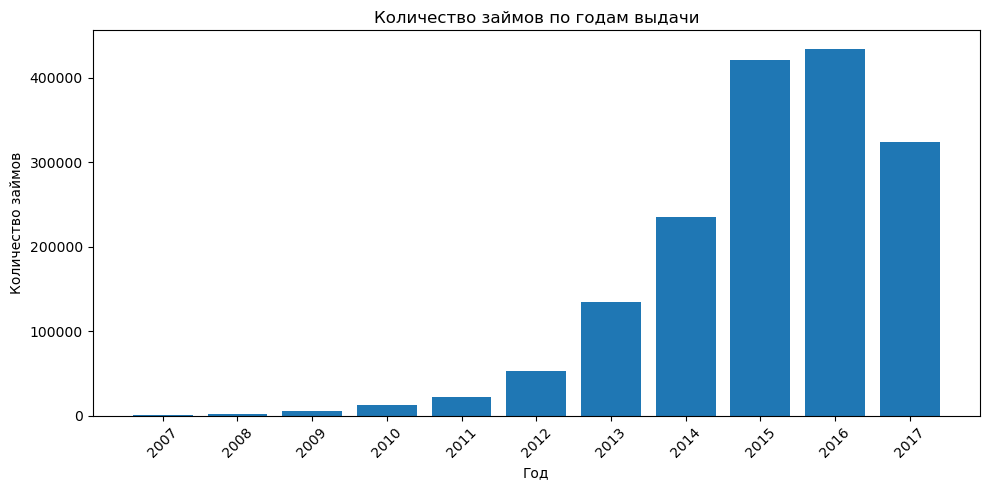

In [12]:
# Переводим агрегат в pandas для построения графика
issue_year_pd = issue_year_stats.toPandas()

# Строим столбчатую диаграмму количества займов по годам
plt.figure(figsize=(10, 5))
plt.bar(issue_year_pd["issue_year"].astype(str), issue_year_pd["loans_cnt"])
plt.title("Количество займов по годам выдачи")
plt.xlabel("Год")
plt.ylabel("Количество займов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Интерпретация
По этому графику можно сделать вывод о том, как менялась активность кредитования от года к году.
З.Ы. Она растет)


# 2. Анализ категориального признака `loan_status`

`loan_status` показывает текущее или итоговое состояние займа:
например, был ли кредит полностью выплачен, находится ли он в просрочке,
или был списан как проблемный.

Этот столбец особенно важен для оценки качества кредитного портфеля.


In [13]:
# Проверяем, есть ли пропуски в статусе займа
count_nulls(df, "loan_status")


Столбец: loan_status
Количество NULL: 0
Доля NULL: 0.0%


In [14]:
# Агрегация по статусу займа:
# - количество займов
# - средняя сумма кредита
# - средняя ставка
# - средний доход заёмщика
# - средний dti
loan_status_stats = (
    df.groupBy("loan_status")
      .agg(
          count("*").alias("loans_cnt"),
          spark_round(avg("loan_amnt"), 2).alias("avg_loan_amnt"),
          spark_round(avg("int_rate"), 2).alias("avg_int_rate"),
          spark_round(avg("annual_inc"), 2).alias("avg_annual_inc"),
          spark_round(avg("dti"), 2).alias("avg_dti")
      )
      .orderBy(col("loans_cnt").desc())
)

loan_status_stats.show(30, truncate=False)


+---------------------------------------------------+---------+-------------+------------+--------------+-------+
|loan_status                                        |loans_cnt|avg_loan_amnt|avg_int_rate|avg_annual_inc|avg_dti|
+---------------------------------------------------+---------+-------------+------------+--------------+-------+
|Current                                            |788081   |15108.58     |12.81       |79627.33      |18.97  |
|Fully Paid                                         |646627   |14037.84     |12.91       |76791.39      |17.29  |
|Charged Off                                        |168033   |15385.48     |15.74       |69263.04      |19.99  |
|Late (31-120 days)                                 |23744    |15831.76     |15.68       |74458.55      |20.29  |
|In Grace Period                                    |10463    |16680.59     |15.23       |77939.34      |19.84  |
|Late (16-30 days)                                  |5782     |16379.22     |15.48      

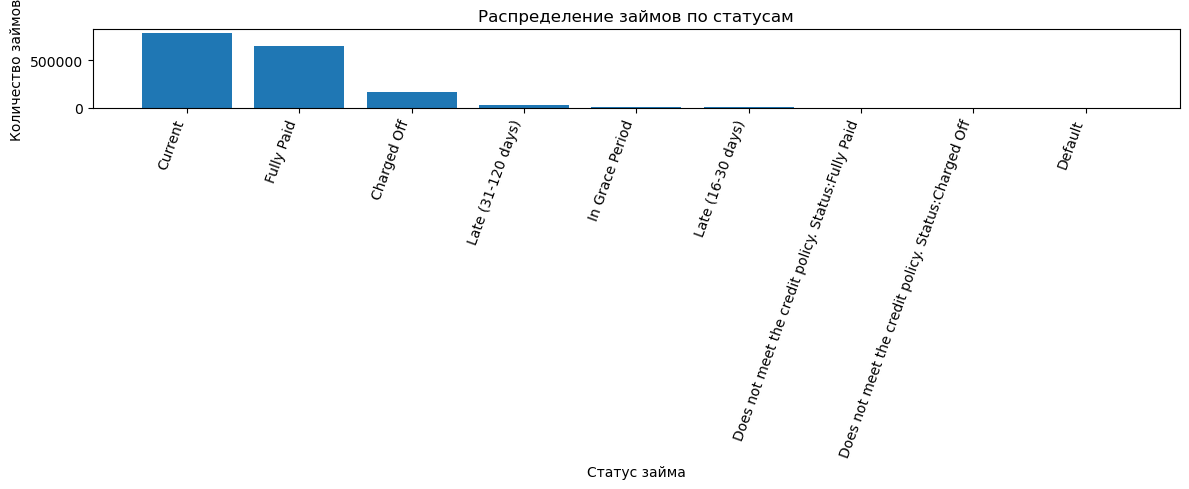

In [15]:
# Визуализация распределения количества займов по статусам
loan_status_pd = loan_status_stats.toPandas()

plt.figure(figsize=(12, 5))
plt.bar(loan_status_pd["loan_status"], loan_status_pd["loans_cnt"])
plt.title("Распределение займов по статусам")
plt.xlabel("Статус займа")
plt.ylabel("Количество займов")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()


# 3. Анализ кредитной категории `grade`

`grade` — это кредитная категория займа.  
Чем хуже категория, тем выше обычно риск и выше ставка.

Этот признак удобен для сравнения:
- уровня риска;
- средней процентной ставки;
- частоты проблемных займов.


In [16]:
# Строим агрегированную статистику по кредитной категории
grade_stats = (
    df.groupBy("grade")
      .agg(
          count("*").alias("loans_cnt"),
          spark_round(avg("loan_amnt"), 2).alias("avg_loan_amnt"),
          spark_round(avg("int_rate"), 2).alias("avg_int_rate"),
          spark_round(avg("annual_inc"), 2).alias("avg_annual_inc"),
          spark_round(avg("is_default"), 4).alias("default_rate")
      )
      .orderBy("grade")
)

grade_stats.show(20, truncate=False)


+-----+---------+-------------+------------+--------------+------------+
|grade|loans_cnt|avg_loan_amnt|avg_int_rate|avg_annual_inc|default_rate|
+-----+---------+-------------+------------+--------------+------------+
|A    |272603   |14030.53     |7.1         |90756.78      |0.0374      |
|B    |485027   |13513.56     |10.62       |78207.99      |0.0776      |
|C    |490334   |14705.4      |14.0        |74059.88      |0.1238      |
|D    |237302   |15663.61     |17.69       |70396.4       |0.1913      |
|E    |111870   |17839.93     |21.14       |71801.44      |0.2545      |
|F    |37383    |19095.79     |24.98       |72764.85      |0.3161      |
|G    |10997    |20344.05     |27.79       |75631.26      |0.3119      |
+-----+---------+-------------+------------+--------------+------------+



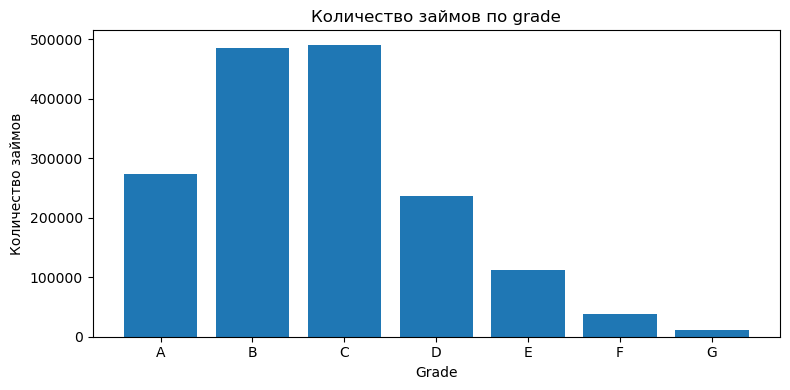

In [17]:
# Количество займов по grade
grade_pd = grade_stats.toPandas()

plt.figure(figsize=(8, 4))
plt.bar(grade_pd["grade"], grade_pd["loans_cnt"])
plt.title("Количество займов по grade")
plt.xlabel("Grade")
plt.ylabel("Количество займов")
plt.tight_layout()
plt.show()


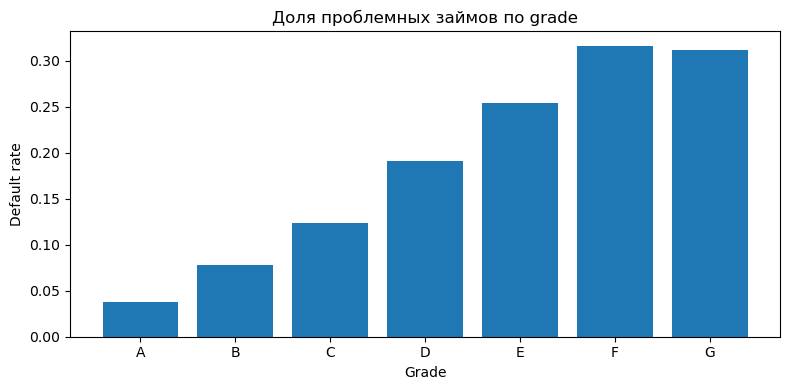

In [18]:
# Доля проблемных займов по grade
plt.figure(figsize=(8, 4))
plt.bar(grade_pd["grade"], grade_pd["default_rate"])
plt.title("Доля проблемных займов по grade")
plt.xlabel("Grade")
plt.ylabel("Default rate")
plt.tight_layout()
plt.show()


### Интерпретация
По этим графикам обычно хорошо видно:
Чем хуже грейд, тем меньше его выдают, кроме "A", видимо таких идеальных клиентов в мире не очень много. Ну и соответсвенное доля проблемных займов увеличивается тем больше, чем хуже оценка. Идеальный клиент кредитной конторы (Ипотечный раб) это челловек, который достаточно ответственен, но нет-нет, да просрочит кредит, а поэтомуможно с него ещё и пени взыскать. 


# 4. Анализ цели кредита `purpose`

`purpose` показывает, на какие цели заёмщик брал кредит:
например, консолидация долгов, кредитная карта, ремонт дома и т.д.

Этот столбец помогает понять:
- какие типы кредитов наиболее популярны;
- какие цели связаны с более высокими рисками.


In [19]:
# Агрегация по цели кредита
purpose_stats = (
    df.groupBy("purpose")
      .agg(
          count("*").alias("loans_cnt"),
          spark_round(avg("loan_amnt"), 2).alias("avg_loan_amnt"),
          spark_round(avg("int_rate"), 2).alias("avg_int_rate"),
          spark_round(avg("is_default"), 4).alias("default_rate")
      )
      .orderBy(col("loans_cnt").desc())
)

purpose_stats.show(20, truncate=False)


+------------------+---------+-------------+------------+------------+
|purpose           |loans_cnt|avg_loan_amnt|avg_int_rate|default_rate|
+------------------+---------+-------------+------------+------------+
|debt_consolidation|955047   |15571.08     |13.61       |0.1287      |
|credit_card       |363721   |15216.27     |11.8        |0.1008      |
|home_improvement  |108959   |14302.8      |12.75       |0.1015      |
|other             |93496    |9894.96      |14.56       |0.1219      |
|major_purchase    |35568    |11896.81     |12.74       |0.1081      |
|medical           |18881    |9085.12      |13.79       |0.1245      |
|small_business    |18576    |15612.41     |15.78       |0.1881      |
|car               |17634    |9048.78      |12.08       |0.0865      |
|moving            |11376    |7916.08      |15.0        |0.1421      |
|vacation          |11148    |6132.42      |13.44       |0.1082      |
|house             |7259     |15134.24     |15.91       |0.1423      |
|weddi

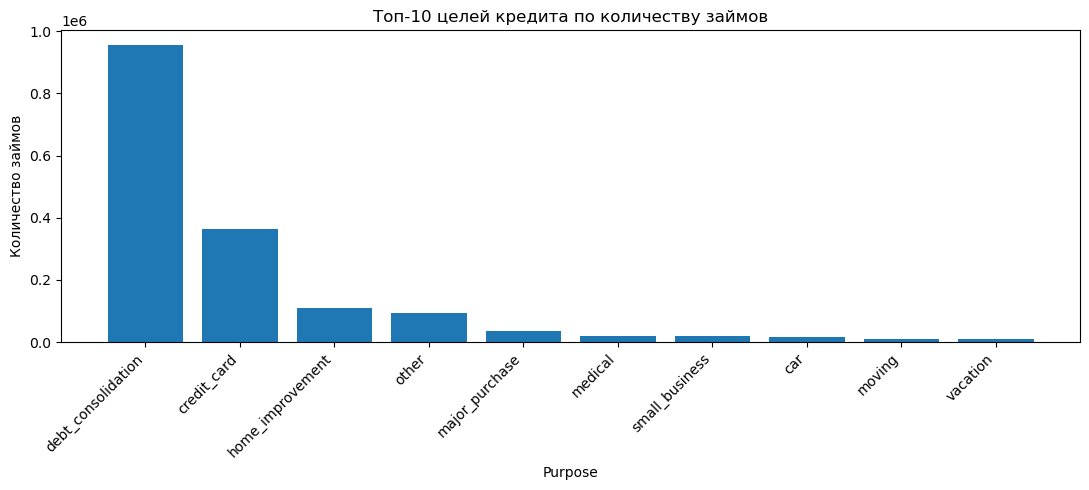

In [20]:
# Визуализируем только 10 наиболее распространённых целей кредита
purpose_pd = purpose_stats.limit(10).toPandas()

plt.figure(figsize=(11, 5))
plt.bar(purpose_pd["purpose"], purpose_pd["loans_cnt"])
plt.title("Топ-10 целей кредита по количеству займов")
plt.xlabel("Purpose")
plt.ylabel("Количество займов")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 5. Анализ количественного признака `loan_amnt`

`loan_amnt` — сумма кредита.  
Это один из ключевых финансовых показателей в датасете.

Сначала посмотрим описательные статистики, затем построим boxplot и гистограмму.


In [21]:
# Базовые статистики для суммы кредита
df.select("loan_amnt").summary("count", "min", "25%", "50%", "75%", "max", "mean", "stddev").show()


+-------+------------------+
|summary|         loan_amnt|
+-------+------------------+
|  count|           1645516|
|    min|             500.0|
|    25%|            8000.0|
|    50%|           12600.0|
|    75%|           20000.0|
|    max|           40000.0|
|   mean|14731.004241222814|
| stddev| 8802.382303853283|
+-------+------------------+



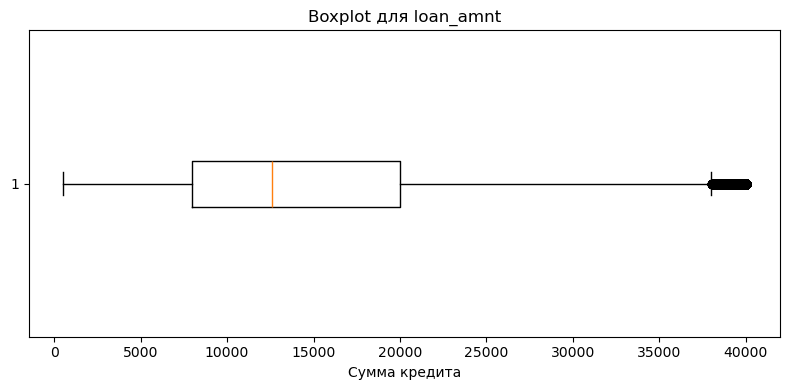

In [22]:
# Boxplot помогает увидеть разброс и выбросы
loan_box_pd = df.select("loan_amnt").toPandas()

plt.figure(figsize=(8, 4))
plt.boxplot(loan_box_pd["loan_amnt"].dropna(), vert=False)
plt.title("Boxplot для loan_amnt")
plt.xlabel("Сумма кредита")
plt.tight_layout()
plt.show()


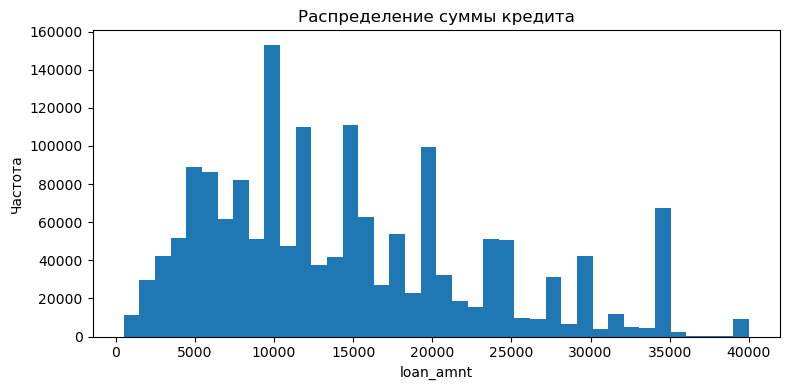

In [23]:
# Гистограмма показывает общую форму распределения
loan_hist_pd = df.select("loan_amnt").toPandas()

plt.figure(figsize=(8, 4))
plt.hist(loan_hist_pd["loan_amnt"].dropna(), bins=40)
plt.title("Распределение суммы кредита")
plt.xlabel("loan_amnt")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


# 6. Анализ количественного признака `int_rate`

`int_rate` — процентная ставка по кредиту.  
Этот признак связан с риском заёмщика и условиями выдачи кредита.


In [24]:
# Описательные статистики для процентной ставки
df.select("int_rate").summary("count", "min", "25%", "50%", "75%", "max", "mean", "stddev").show()


+-------+------------------+
|summary|          int_rate|
+-------+------------------+
|  count|           1645516|
|    min|              5.32|
|    25%|              9.76|
|    50%|             12.74|
|    75%|             15.99|
|    max|             30.99|
|   mean|13.217582612428046|
| stddev| 4.703824689269381|
+-------+------------------+



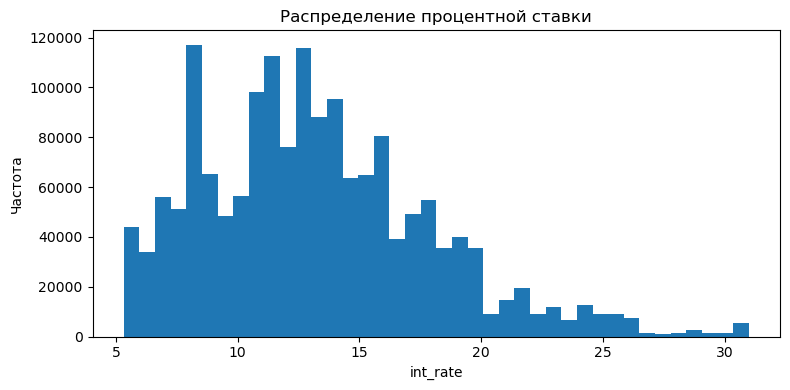

In [25]:
# Гистограмма для процентной ставки
int_rate_pd = df.select("int_rate").toPandas()

plt.figure(figsize=(8, 4))
plt.hist(int_rate_pd["int_rate"].dropna(), bins=40)
plt.title("Распределение процентной ставки")
plt.xlabel("int_rate")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


# 7. Анализ признака `annual_inc`

`annual_inc` — годовой доход заёмщика.  
В этом признаке обычно встречаются очень большие выбросы.

Поэтому здесь важно показать графики в двух вариантах:
1. по полному диапазону;
2. по основной массе данных без самых экстремальных значений.

Именно поэтому строятся:
- boxplot по полному диапазону;
- boxplot до 95-го процентиля;
- гистограмма до 95-го процентиля.

Так распределение становится гораздо лучше читаемым.


In [26]:
# Описательные статистики для annual_inc
df.select("annual_inc").summary("count", "min", "25%", "50%", "75%", "max", "mean", "stddev").show()


+-------+----------------+
|summary|      annual_inc|
+-------+----------------+
|  count|         1645516|
|    min|           600.0|
|    25%|         46200.0|
|    50%|         65000.0|
|    75%|         92000.0|
|    max|           1.1E8|
|   mean|77347.8692088437|
| stddev|120758.493028211|
+-------+----------------+



In [27]:
# Считаем ключевые квантили распределения дохода
# Они нужны, чтобы отделить основную массу наблюдений от выбросов
annual_inc_quantiles = df.approxQuantile("annual_inc", [0.5, 0.75, 0.95, 0.99, 0.995, 0.999], 0.001)
annual_inc_quantiles


[65000.0, 92000.0, 160000.0, 260000.0, 325000.0, 110000000.0]

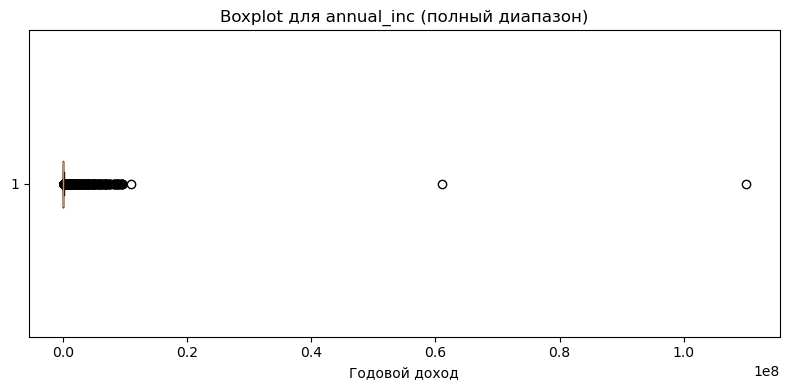

In [28]:
# Полный boxplot по annual_inc
# Здесь видно, что экстремальные выбросы сильно растягивают ось
annual_inc_pd = df.select("annual_inc").toPandas()

plt.figure(figsize=(8, 4))
plt.boxplot(annual_inc_pd["annual_inc"].dropna(), vert=False)
plt.title("Boxplot для annual_inc (полный диапазон)")
plt.xlabel("Годовой доход")
plt.tight_layout()
plt.show()


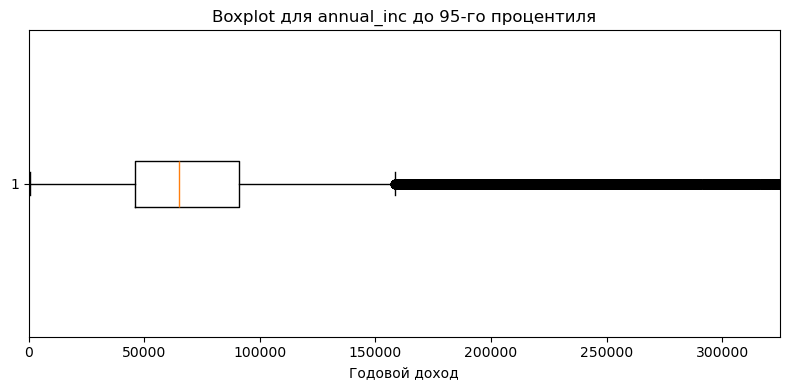

In [29]:
# Ограничиваем данные 95-м процентилем, чтобы показать основную массу наблюдений
annual_inc_p95 = annual_inc_quantiles[4]
annual_inc_main = df.filter(col("annual_inc") <= annual_inc_p95)
annual_inc_main_pd = annual_inc_main.select("annual_inc").toPandas()

plt.figure(figsize=(8, 4))
plt.boxplot(annual_inc_main_pd["annual_inc"].dropna(), vert=False)
plt.title("Boxplot для annual_inc до 95-го процентиля")
plt.xlabel("Годовой доход")
plt.xlim(0, annual_inc_p95)
plt.tight_layout()
plt.show()


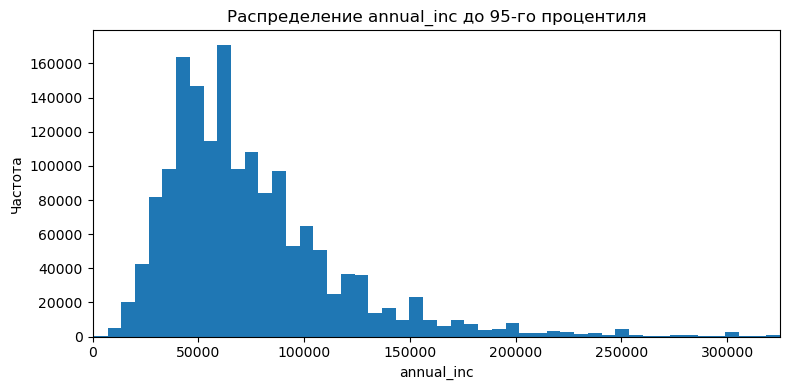

In [30]:
# Гистограмма по основной массе доходов до 95-го процентиля
# Такой график уже гораздо лучше показывает форму распределения
plt.figure(figsize=(8, 4))
plt.hist(annual_inc_main_pd["annual_inc"].dropna(), bins=50)
plt.title("Распределение annual_inc до 95-го процентиля")
plt.xlabel("annual_inc")
plt.ylabel("Частота")
plt.xlim(0, annual_inc_p95)
plt.tight_layout()
plt.show()


# 8. Анализ признака `dti`

`dti` — отношение долговой нагрузки к доходу (Debt-to-Income ratio).  
Это важный показатель платёжеспособности заёмщика.

Чем выше `dti`, тем больше долговая нагрузка по отношению к доходу.


In [31]:
# Описательные статистики для dti
df.select("dti").summary("count", "min", "25%", "50%", "75%", "max", "mean", "stddev").show()


+-------+------------------+
|summary|               dti|
+-------+------------------+
|  count|           1645516|
|    min|               0.0|
|    25%|             12.07|
|    50%|             17.88|
|    75%|             24.31|
|    max|             100.0|
|   mean|18.433805007061878|
| stddev| 8.640036999485362|
+-------+------------------+



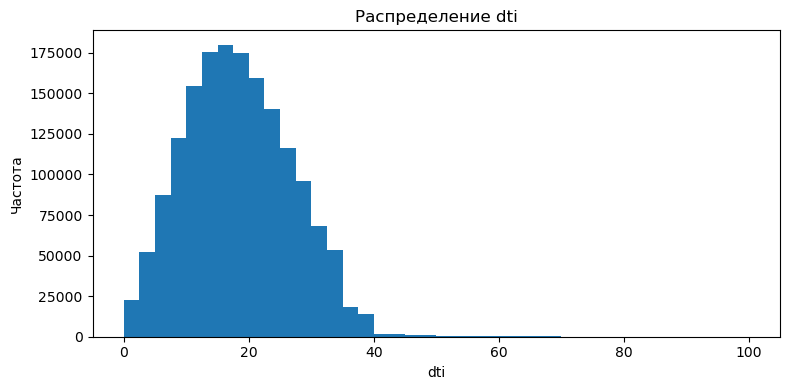

In [32]:
# Гистограмма для dti
dti_pd = df.select("dti").toPandas()

plt.figure(figsize=(8, 4))
plt.hist(dti_pd["dti"].dropna(), bins=40)
plt.title("Распределение dti")
plt.xlabel("dti")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


# 9. Корреляционный анализ количественных признаков

Корреляционная матрица нужна, чтобы оценить, есть ли линейная зависимость между количественными признаками.

Важно:
- сюда включаются только **непрерывные количественные признаки**;
- бинарный признак `is_default` мы **не включаем**, потому что его корректнее анализировать отдельно.


In [33]:
def compute_and_visualize_correlation_matrix(data: DataFrame, columns: list[str]) -> None:
    """
    Строит корреляционную матрицу по выбранным количественным признакам
    и визуализирует её.
    """
    pandas_df = data.select(*columns).toPandas()
    corr_matrix = pandas_df.corr(numeric_only=True)

    print(corr_matrix)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(columns)), columns, rotation=45, ha="right")
    plt.yticks(range(len(columns)), columns)
    plt.title("Корреляционная матрица")
    plt.tight_layout()
    plt.show()


             loan_amnt  int_rate  annual_inc       dti  term_months
loan_amnt     1.000000  0.140468    0.188741  0.043669     0.397835
int_rate      0.140468  1.000000   -0.046942  0.180313     0.395951
annual_inc    0.188741 -0.046942    1.000000 -0.100638     0.035553
dti           0.043669  0.180313   -0.100638  1.000000     0.086009
term_months   0.397835  0.395951    0.035553  0.086009     1.000000


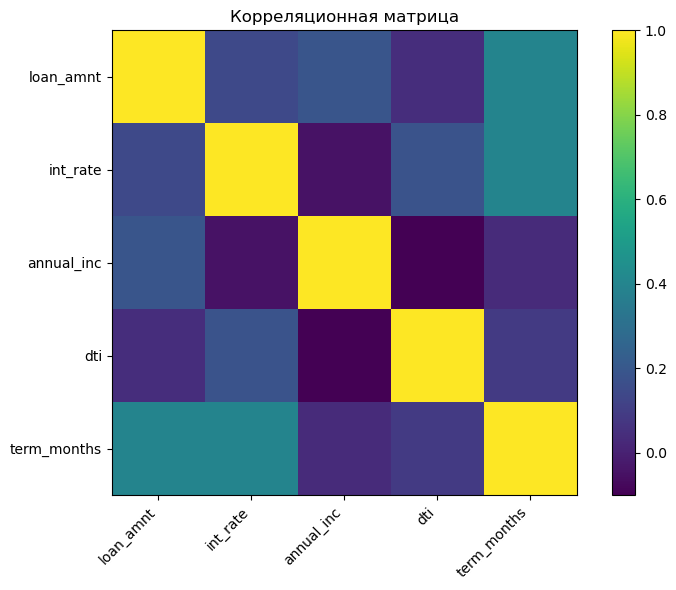

In [34]:
# В матрицу включаем только количественные признаки
compute_and_visualize_correlation_matrix(
    data=df,
    columns=[
        "loan_amnt",
        "int_rate",
        "annual_inc",
        "dti",
        "term_months"
    ]
)


In [35]:
# Доля проблемных займов по кредитной категории
df.groupBy("grade").agg(
    count("*").alias("loans_cnt"),
    spark_round(avg("is_default"), 4).alias("default_rate")
).orderBy("grade").show()


+-----+---------+------------+
|grade|loans_cnt|default_rate|
+-----+---------+------------+
|    A|   272603|      0.0374|
|    B|   485027|      0.0776|
|    C|   490334|      0.1238|
|    D|   237302|      0.1913|
|    E|   111870|      0.2545|
|    F|    37383|      0.3161|
|    G|    10997|      0.3119|
+-----+---------+------------+



In [36]:
# Доля проблемных займов по цели кредита
default_by_purpose = (
    df.groupBy("purpose")
      .agg(
          count("*").alias("loans_cnt"),
          spark_round(avg("is_default"), 4).alias("default_rate")
      )
      .orderBy(col("default_rate").desc())
)

default_by_purpose.show(20, truncate=False)


+------------------+---------+------------+
|purpose           |loans_cnt|default_rate|
+------------------+---------+------------+
|small_business    |18576    |0.1881      |
|renewable_energy  |1094     |0.1572      |
|house             |7259     |0.1423      |
|moving            |11376    |0.1421      |
|educational       |411      |0.1314      |
|debt_consolidation|955047   |0.1287      |
|medical           |18881    |0.1245      |
|other             |93496    |0.1219      |
|wedding           |2346     |0.1185      |
|vacation          |11148    |0.1082      |
|major_purchase    |35568    |0.1081      |
|home_improvement  |108959   |0.1015      |
|credit_card       |363721   |0.1008      |
|car               |17634    |0.0865      |
+------------------+---------+------------+



# 11. Финальная обработка и сохранение

На этом этапе формируется финальный набор данных для сохранения.

Здесь дополнительно убираются экстремальные выбросы по `annual_inc`
выше 95-го процентиля. Это позволяет сделать итоговую таблицу более устойчивой
для дальнейшего анализа.


In [37]:
# Формируем итоговый датафрейм без экстремальных выбросов по annual_inc
processed_df = df.filter(col("annual_inc") <= annual_inc_p95)

# Проверяем количество строк
processed_df.count()


1637029

In [38]:
# Имя таблицы для сохранения результата второй части
processed_table_name = "sobd_lab1_lending_club_processed"

# Если таблица уже существует, удаляем её
spark.sql(f"DROP TABLE IF EXISTS spark_catalog.{database_name}.{processed_table_name}")

# Сохраняем обработанный датафрейм в Iceberg
processed_df.writeTo(
    f"spark_catalog.{database_name}.{processed_table_name}"
).using("iceberg").create()


In [39]:
# Смотрим, какие таблицы есть в базе
for table in spark.catalog.listTables(database_name):
    print(table.name)


sobd_lab1_lending_club_table
sobd_lab1_lending_club_processed


In [40]:
# Проверяем содержимое сохранённой таблицы
df_processed_table = spark.table(f"spark_catalog.{database_name}.{processed_table_name}")
df_processed_table.show(10, truncate=False)


+------+---------+----------+--------+-----+----------+--------+--------------------------------------------------+------------------+-----+-----------+----------+----------+-----------+----------+
|id    |loan_amnt|term      |int_rate|grade|annual_inc|issue_d |loan_status                                       |purpose           |dti  |term_months|issue_date|issue_year|issue_month|is_default|
+------+---------+----------+--------+-----+----------+--------+--------------------------------------------------+------------------+-----+-----------+----------+----------+-----------+----------+
|54734 |25000.0  | 36 months|11.89   |B    |85000.0   |Aug-2009|Fully Paid                                        |debt_consolidation|19.48|36         |2009-08-01|2009      |8          |0         |
|61390 |4000.0   | 36 months|7.88    |A    |148000.0  |Feb-2010|Fully Paid                                        |credit_card       |16.98|36         |2010-02-01|2010      |2          |0         |
|65419 |16

# Завершение работы

После завершения анализа Spark-сессию следует остановить.
Это освобождает ресурсы и корректно завершает выполнение ноутбука.


In [41]:
# Останавливаем SparkSession
spark.stop()
